# Goal-Conditioned RL for Complex Tasks

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand goal-conditioned RL
- Implement goal-conditioned policies
- Apply to complex multi-task problems
- Understand universal value functions

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of value functions
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing goal-conditioned RL for complex tasks

---

## Introduction

**Goal-conditioned RL** learns policies that can achieve different goals, enabling generalization across tasks and efficient multi-task learning.

## Lesson Brief

This lesson introduces goal-conditioned RL, where the same environment can present different targets and the policy must adapt to each one.

Students will see why the goal itself becomes part of the decision problem.

Why this matters: many practical systems must solve many related tasks, not only one fixed task forever.

This lesson shows how RL can generalize across goals.

## Recommended YouTube Video

To reinforce this lesson, watch **Olivier Sigaud - "Goal-conditioned reinforcement learning: hindsight experience replay"**:
[Watch on YouTube](https://www.youtube.com/watch?v=0EDiC__RcCA)

Why this pick:
- Clear academic English and very focused topic coverage.
- Explains goal-conditioned RL through hindsight experience replay in a compact way.
- Good for students who need the key idea without a long detour into unrelated deep RL topics.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Goal-conditioned policy: acts based on a target goal.
- Goal signal: the requested outcome.
- Generalization across goals: one learner for many related targets.
- Success criterion: how we judge goal completion.
- Universal value function idea: value estimates depend on both state and goal.

### Quick Check
- Why include the goal in the input?
- How is this different from one fixed task?
- What flexibility does this add?
- Why is goal-conditioned RL not automatically the same as meta-learning?

### Common Mistakes
- Thinking every new goal needs a new agent.
- Forgetting the goal is part of the input.
- Confusing current state with target state.
- Treating goal-conditioned RL, multi-task learning, and few-shot learning as identical ideas.


## Goal-Conditioned RL Is Not the Same as Meta-Learning

This distinction is important because students often mix several advanced ideas together.

### Goal-conditioned RL

Goal-conditioned RL says:

`Use the current state and the requested goal together when choosing actions.`

The same learner can then solve many related targets inside one environment.

### Meta-learning

Meta-learning asks a different question:

`How can a learner adapt quickly to a new task from limited experience?`

That is a broader adaptation problem.

### The connection

Goal-conditioned RL can support multi-goal behavior and some kinds of generalization.
But it is **not automatically** a full few-shot or meta-learning method.

### Teaching takeaway

Students should leave this notebook saying:

- goal-conditioned RL -> one policy, many goals
- meta-learning -> fast adaptation across tasks

They are related, but not identical.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np

print("✅ Libraries imported!")
print("\nGoal-Conditioned RL for Complex Tasks")
print("=" * 60)

print("\nGoal-Conditioned RL:")
print("  - Policy: π(a|s,g) - action given state AND goal")
print("  - Value: Q(s,a,g) or V(s,g) - value given goal")
print("  - Universal: Works for any goal")

print("\nBenefits:")
print("  - Multi-task learning")
print("  - Generalization")
print("  - Few-shot learning")
print("  - Hierarchical abstraction")

print("\nApplications:")
print("  - Robotics (reach different positions)")
print("  - Navigation (reach different locations)")
print("  - Manipulation (achieve different states)")

print("\n✅ Goal-conditioned RL concepts understood!")

✅ Libraries imported!

Goal-Conditioned RL for Complex Tasks

Goal-Conditioned RL:
  - Policy: π(a|s,g) - action given state AND goal
  - Value: Q(s,a,g) or V(s,g) - value given goal
  - Universal: Works for any goal

Benefits:
  - Multi-task learning
  - Generalization
  - Few-shot learning
  - Hierarchical abstraction

Applications:
  - Robotics (reach different positions)
  - Navigation (reach different locations)
  - Manipulation (achieve different states)

✅ Goal-conditioned RL concepts understood!


## Worked Example: One Policy, Many Goals

A goal-conditioned agent does not learn only `what action is good in this state?`

It learns:

`what action is good in this state for this specific goal?`

That matters when the same environment can ask for different targets, such as:
- reach different shelves in a warehouse
- move a robot arm to different coordinates
- navigate to different rooms in a building

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np

GRID_SIZE = 5
START = (2, 2)
GOALS = [(0, 4), (4, 0), (0, 0)]


def goal_conditioned_action(state, goal):
    row, col = state
    goal_row, goal_col = goal
    if row < goal_row:
        return "down"
    if row > goal_row:
        return "up"
    if col < goal_col:
        return "right"
    if col > goal_col:
        return "left"
    return "stay"


def apply_action(state, action):
    row, col = state
    if action == "up":
        row -= 1
    elif action == "down":
        row += 1
    elif action == "left":
        col -= 1
    elif action == "right":
        col += 1
    row = min(max(row, 0), GRID_SIZE - 1)
    col = min(max(col, 0), GRID_SIZE - 1)
    return (row, col)


def rollout_to_goal(start, goal):
    state = start
    trajectory = [state]
    actions = []
    while state != goal:
        action = goal_conditioned_action(state, goal)
        actions.append(action)
        state = apply_action(state, action)
        trajectory.append(state)
        if len(trajectory) > 20:
            break
    return actions, trajectory


for goal in GOALS:
    actions, trajectory = rollout_to_goal(START, goal)
    print(f"Goal: {goal}")
    print(" Actions:", actions)
    print(" Trajectory:", trajectory)
    print()

print("Teaching point:")
print("The decision rule changes when the goal changes, even if the current state stays the same.")
print("That is the central idea of goal-conditioned RL.")

Goal: (0, 4)
 Actions: ['up', 'up', 'right', 'right']
 Trajectory: [(2, 2), (1, 2), (0, 2), (0, 3), (0, 4)]

Goal: (4, 0)
 Actions: ['down', 'down', 'left', 'left']
 Trajectory: [(2, 2), (3, 2), (4, 2), (4, 1), (4, 0)]

Goal: (0, 0)
 Actions: ['up', 'up', 'left', 'left']
 Trajectory: [(2, 2), (1, 2), (0, 2), (0, 1), (0, 0)]

Teaching point:
The decision rule changes when the goal changes, even if the current state stays the same.
That is the central idea of goal-conditioned RL.


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## Summary

This notebook showed why goal-conditioned RL is useful:

- the environment can stay the same
- the desired goal can change from episode to episode
- the policy must therefore depend on both **state** and **goal**

### Main takeaway

Goal-conditioned policies are a natural fit for multi-target tasks such as
navigation, robotics, and manipulation, where one agent must solve many related
objectives instead of only one fixed task.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


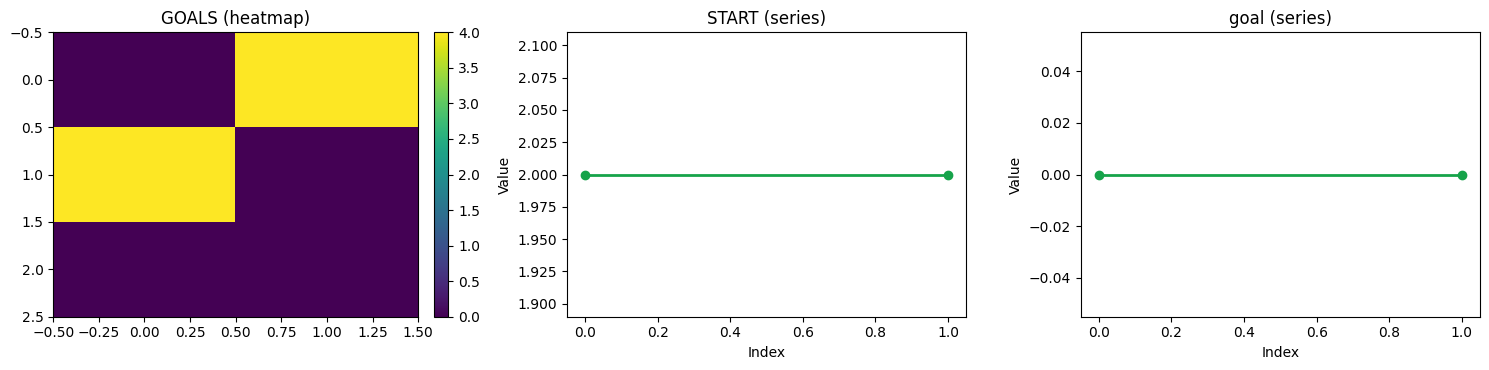

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Goal-conditioned RL trains one policy to solve many targets by making the goal part of the agent input.

**If students remember one idea:** A policy can become more flexible when it is trained to answer not only what state it is in, but also what outcome it should reach.

**Quick check before moving on:**
- Can you explain what changes in the policy input when goals are included explicitly?
- Can you describe why goal-conditioned learning can support reuse across many tasks?

**Bridge to the next step:** This completes the advanced applications unit and helps students see how RL ideas generalize beyond one fixed task.
